In [34]:
!pip install tensorflow
!pip install keras
!pip install pyforest

In [32]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
#import data
df=pd.read_csv("/content/kenya_inflation.csv")

In [9]:
df.info()
df.describe()
df.isna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    64 non-null     int64  
 1   CPI     64 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


,Year,CPI
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
59,False,False
60,False,False
61,False,False
62,False,False


Text(0, 0.5, 'CPI')

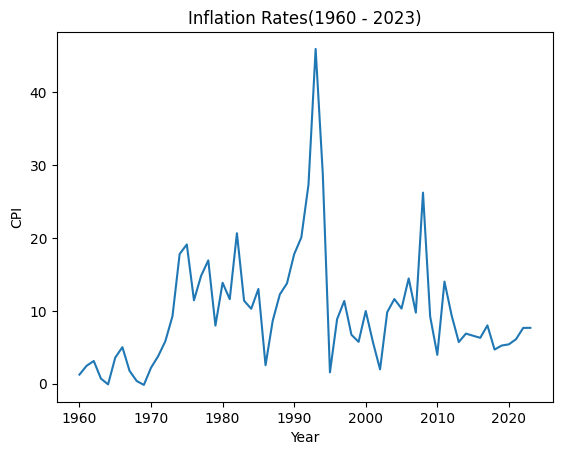

In [8]:
#Draw a line graph
plt.plot(df['Year'],df['CPI'])
plt.title('Inflation Rates(1960 - 2023)')
plt.xlabel('Year')
plt.ylabel('CPI')

In [10]:
#Spliting Data(Selecting Variables; seelcting x and y[target] variables)
x=df[['Year']]
y=df['CPI']

In [12]:
#Standadize the Model
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
x_scaled=Scaler.fit_transform(x)

In [23]:
#Split the Dataset into 0.8 and 0.2
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [35]:
#Model Selection
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer: predicting a single continuous value (CPI)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
#Compiling the model (Helps in getting the Mean Absolute Error and Loss)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

Test Loss: 6.4036, Test MAE: 1.9562
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

Predicted Inflation for the Next 5 Years:
   Year  Predicted CPI
0  2024       5.872533
1  2025       5.739316
2  2026       5.610137
3  2027       5.480957
4  2028       5.364373


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


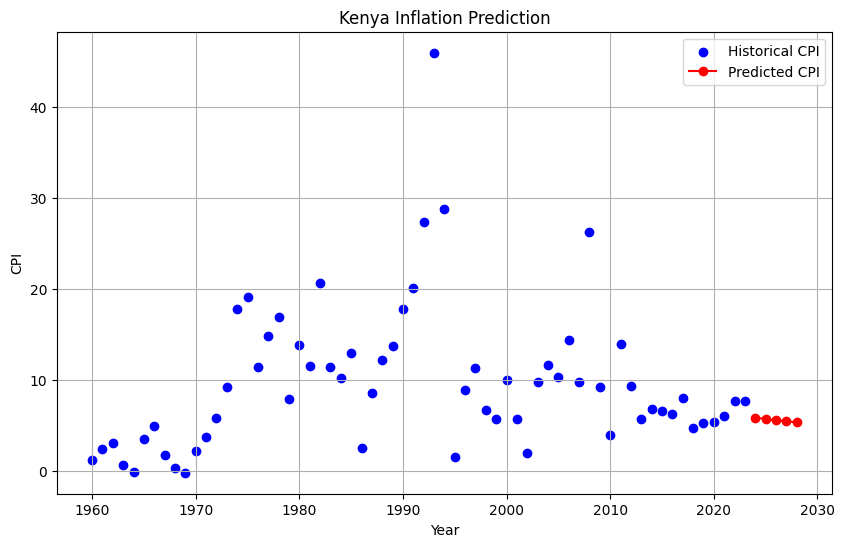

In [44]:
#Train the model
history = model.fit(x_train, y_train, epochs=200, batch_size=8,
                    validation_data=(x_test, y_test), verbose=0)

# Evaluate the model on the test set
loss, mae = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

# Predict inflation for the next 5 years
# Define future years for prediction
future_years = np.array([[2024], [2025], [2026], [2027], [2028]])
# Scale these years using the same scaler used for training data
future_years_Scaled = Scaler.transform(future_years)

# Generate predictions
future_predictions = model.predict(future_years_Scaled)

# Create a DataFrame to display the results
future_df = pd.DataFrame({
    'Year': future_years.flatten(),
    'Predicted CPI': future_predictions.flatten()
})
print("\nPredicted Inflation for the Next 5 Years:")
print(future_df)

# Plot historical data and predictions
plt.figure(figsize=(10, 6))
plt.scatter(df['Year'], df['CPI'], label='Historical CPI', color='blue')
plt.plot(future_df['Year'], future_df['Predicted CPI'], marker='o', linestyle='-', color='red', label='Predicted CPI')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.title('Kenya Inflation Prediction')
plt.legend()
plt.grid(True)
plt.show()